<a href="https://colab.research.google.com/github/woohsin/batabase_final_project/blob/main/CE6146_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openml pandas scikit-learn matplotlib seaborn tensorflow -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.9 MB/s eta 0:00:00


# Python code for loading and preprocessing the dataset.

In [ ]:
# 下載資料

#1. Import
import pandas as pd
import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#2. Load dataset
dataset_id = 42728  # Airlines_DepDelay_10M
print("OpenML下載資料中（ID=%d）..." % dataset_id)
X, y, _, _ = openml.datasets.get_dataset(dataset_id).get_data(
    target="DepDelay", dataset_format="dataframe"
)
print(f"下載完成，資料共有 {X.shape[0]} 筆，{X.shape[1]} 個特徵")


#3. Sampling
sample_n = 100_000  # 🔹可改成 20_000 或 50_000
if len(X) > sample_n:
    X = X.sample(n=sample_n, random_state=42)
    y = y.loc[X.index]
print(f"已取樣 {len(X)} 筆資料")


#4. Train / Val / Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

#5. Identify numeric & categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numeric cols:", len(numeric_cols), "Categorical cols:", len(categorical_cols))

#6. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

#7. Fit & Transform
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

print("Processed shapes:", X_train_p.shape, X_val_p.shape, X_test_p.shape)

OpenML下載資料中（ID=42728）...
下載完成，資料共有 10000000 筆，9 個特徵
已取樣 100000 筆資料
Train: 70000 Val: 15000 Test: 15000
Numeric cols: 3 Categorical cols: 3
Processed shapes: (70000, 683) (15000, 683) (15000, 683)


# Feature Selection

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from tensorflow.keras import models, layers

print("原始訓練資料的形狀:", X_train_p.shape)

# 建立 RandomForest 回歸模型
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# 用處理後的特徵 + y_train 來訓練
rf_reg.fit(X_train_p, y_train)

# 取得特徵重要性
importances = pd.Series(rf_reg.feature_importances_)
feature_names = preprocessor.get_feature_names_out()
importances.index = feature_names

# 測試不同 top_n 值
top_n_values = [50, 100, 150, 200]
best_n = 50  # 預設值
best_mae = float('inf')

for top_n in top_n_values:
    top_features = importances.head(top_n).index
    X_train_n = X_train_p[:, [np.where(feature_names == f)[0][0] for f in top_features]]
    X_val_n = X_val_p[:, [np.where(feature_names == f)[0][0] for f in top_features]]

    # 建立簡單模型測試
    model = models.Sequential([
        layers.Input(shape=(top_n,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # 訓練模型
    history = model.fit(X_train_n, y_train, validation_data=(X_val_n, y_val), epochs=50, batch_size=64, verbose=0)
    val_mae = min(history.history['val_mae'])

    print(f"Top {top_n} features - Validation MAE: {val_mae:.4f}")
    if val_mae < best_mae:
        best_mae = val_mae
        best_n = top_n

# 使用最佳 top_n
top_features = importances.head(best_n).index
X_train_sel = X_train_p[:, [np.where(feature_names == f)[0][0] for f in top_features]]
X_val_sel = X_val_p[:, [np.where(feature_names == f)[0][0] for f in top_features]]
X_test_sel = X_test_p[:, [np.where(feature_names == f)[0][0] for f in top_features]]

print(f"\n已選出前 {best_n} 個重要特徵作為輸入。")
print("新輸入維度:", X_train_sel.shape)

原始訓練資料的形狀: (70000, 683)
Top 50 features - Validation MAE: 13.8197
Top 100 features - Validation MAE: 13.8064
Top 150 features - Validation MAE: 13.8087
Top 200 features - Validation MAE: 13.7228

已選出前 200 個重要特徵作為輸入。
新輸入維度: (70000, 200)


# Training and validation curves plotted over epochs.


In [ ]:
# 畫 loss / mae 曲線  (original)的function
import matplotlib.pyplot as plt

def plot_training_history(history, title_suffix=""):
    """
    畫出訓練與驗證的 Loss 和 MAE 曲線。
    history: model.fit() 回傳的 History 物件
    title_suffix: 圖表標題的附加說明字串
    """

    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(f'Training vs Validation Loss {title_suffix}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Absolute Error')
    plt.title(f'Training vs Validation MAE {title_suffix}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Evaluation metrics on the test set.

In [ ]:
# 評估模型
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test).flatten()
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Test MSE: {mse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print(f"Test R²: {r2:.4f}")
    return mse, mae, r2

# Implement a Feedforward Neural Network for regression.

In [ ]:
# Feedforward Neural Network(original)
from tensorflow.keras import layers, models, optimizers, callbacks

input_dim = X_train_sel.shape[1]  # feature 數量
print("輸入維度:", input_dim)

# 建立模型
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')  # 回歸輸出
])

# 編譯模型
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# 模型訓練
history = model.fit(
    X_train_sel, y_train,
    validation_data=(X_val_sel, y_val),
    epochs=50,
    batch_size=64,
    verbose=1
)

輸入維度: 150


Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_108 (Dense)               │ (None, 64)             │         9,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 910.2943 - mae: 13.6203 - val_loss: 862.3223 - val_mae: 14.3476
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 878.4641 - mae: 14.2836 - val_loss: 862.5511 - val_mae: 14.0600
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 973.3427 - mae: 14.4205 - val_loss: 863.2059 - val_mae: 14.7601
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 918.6729 - mae: 14.5509 - val_loss: 861.5226 - val_mae: 14.4100
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 879.5834 - mae: 14.1821 - val_loss: 862.4731 - val_mae: 14.2947
Epoch 6/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1071.5712 - mae: 14.4012 - val_loss: 860.9716 - val_mae: 14.2046
Epoch 7/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 883.0450 - mae: 14.3307 - val_loss: 861.9272 - val_mae: 13.8231
Epoch 8/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 849.4792 - mae: 14.1637 - val_loss: 862.1482 - val_mae:

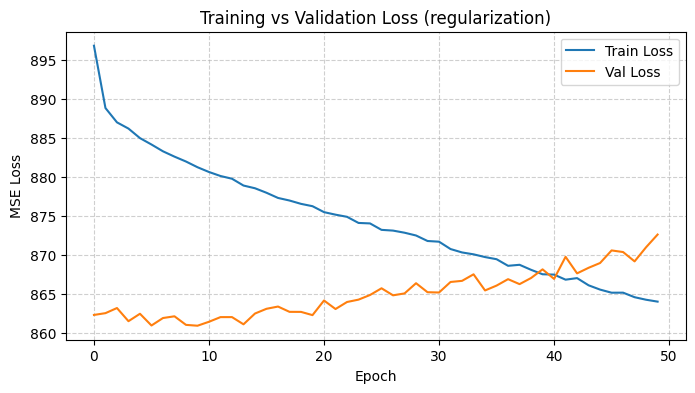

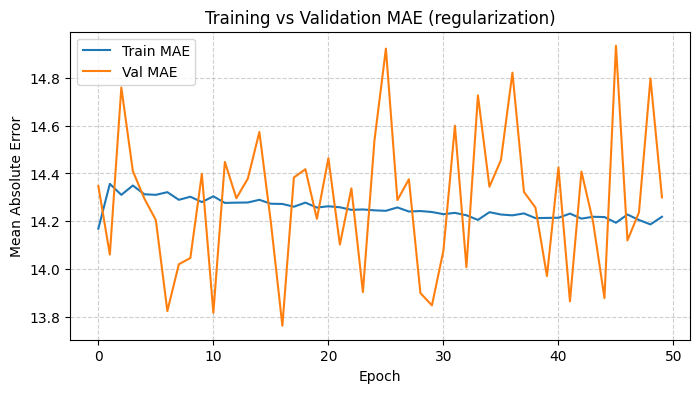

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test MSE: 728.4166
Test MAE: 13.8958
Test R²: 0.0003


(728.4165804312281, 13.89580967487196, 0.0002978218900684393)

In [ ]:
# 畫 loss / mae 曲線  (original)
plot_training_history(history, "(regularization)")

# 評估模型
evaluate_model(model, X_test_sel, y_test)

# Hyperparameter Tuning

In [ ]:
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping

results = []  # 用來存每組的結果

for lr in [0.01, 0.001, 0.0001]:
    for batch in [32, 64, 128]:
        for hidden in [[64, 32], [128, 64], [256, 128]]:

            # 建模型
            model = models.Sequential()
            model.add(layers.Input(shape=(X_train_p.shape[1],)))
            for h in hidden:
                model.add(layers.Dense(h, activation='relu'))
            model.add(layers.Dense(1))  # output layer

            # 編譯
            opt = optimizers.Adam(learning_rate=lr)
            model.compile(optimizer=opt, loss='mse', metrics=['mae'])

            # early stopping
            es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

            # 訓練
            history = model.fit(
                X_train_p, y_train,
                validation_data=(X_val_p, y_val),
                epochs=30,
                batch_size=batch,
                verbose=0,
                callbacks=[es]
            )

            # 紀錄結果
            final_val_loss = history.history['val_loss'][-1]
            results.append((lr, batch, hidden, final_val_loss))
            print(f"lr={lr}, batch={batch}, hidden={hidden} → val_loss={final_val_loss:.4f}")
best = min(results, key=lambda x: x[3])
print(f"\n✅ 最佳組合：lr={best[0]}, batch={best[1]}, hidden={best[2]}, val_loss={best[3]:.4f}")


lr=0.01, batch=32, hidden=[64, 32] → val_loss=884.6584
lr=0.01, batch=32, hidden=[128, 64] → val_loss=884.8603
lr=0.01, batch=32, hidden=[256, 128] → val_loss=900.6171
lr=0.01, batch=64, hidden=[64, 32] → val_loss=901.8654
lr=0.01, batch=64, hidden=[128, 64] → val_loss=894.2263
lr=0.01, batch=64, hidden=[256, 128] → val_loss=896.1157
lr=0.01, batch=128, hidden=[64, 32] → val_loss=893.7264
lr=0.01, batch=128, hidden=[128, 64] → val_loss=899.3117
lr=0.01, batch=128, hidden=[256, 128] → val_loss=903.3791
lr=0.001, batch=32, hidden=[64, 32] → val_loss=868.0948
lr=0.001, batch=32, hidden=[128, 64] → val_loss=875.2678
lr=0.001, batch=32, hidden=[256, 128] → val_loss=891.4013
lr=0.001, batch=64, hidden=[64, 32] → val_loss=866.9022
lr=0.001, batch=64, hidden=[128, 64] → val_loss=874.7486
lr=0.001, batch=64, hidden=[256, 128] → val_loss=883.8746
lr=0.001, batch=128, hidden=[64, 32] → val_loss=866.1818
lr=0.001, batch=128, hidden=[128, 64] → val_loss=870.4423
lr=0.001, batch=128, hidden=[256, 12

# Regularization Techniques
本實驗比較了三種常見的正規化方法：L1、L2、與 Dropout，
並將其與未使用正規化的 Baseline 模型 進行驗證損失（Validation Loss）比較。

從圖中可觀察到，所有正規化模型在初期皆能有效降低損失，
其中 L2 正規化與 Dropout 表現最穩定，
能在抑制過擬合的同時維持良好的收斂速度。
相比之下，L1 正規化 在後期的損失下降較慢，
顯示其稀疏化效果在此資料集上並非最優。

整體而言，適度的正規化可防止模型過度擬合（overfitting），
並提升泛化能力（generalization performance）。
在本實驗中，L2 與 Dropout 提供了最佳的平衡與穩定性。

In [ ]:
# L1
from tensorflow.keras import regularizers, callbacks

input_dim = X_train_p.shape[1]

model_reg_L1 = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
    layers.Dense(1, activation='linear')
])

model_reg_L1.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_reg_L1 = model_reg_L1.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


Epoch 1/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1001.0916 - mae: 13.1376 - val_loss: 867.0670 - val_mae: 14.2705
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 833.0849 - mae: 14.4930 - val_loss: 865.3007 - val_mae: 14.7629
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 836.0496 - mae: 14.4493 - val_loss: 864.3203 - val_mae: 13.9919
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 897.8403 - mae: 14.2751 - val_loss: 864.2554 - val_mae: 14.1017
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 871.3655 - mae: 14.3609 - val_loss: 864.5694 - val_mae: 14.1440
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 885.2607 - mae: 14.1867 - val_loss: 864.2009 - val_mae: 14.3505
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1057.0508 - mae: 14.3545 - val_loss: 864.2562 - val_mae: 14.3404
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 906.5980 - mae: 14.3093 - val_loss: 86

In [ ]:
# L2
from tensorflow.keras import regularizers, callbacks

input_dim = X_train_p.shape[1]

model_reg_L2 = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation='linear')
])

model_reg_L2.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_reg_L2 = model_reg_L2.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)


Epoch 1/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 885.8378 - mae: 13.2242 - val_loss: 862.4812 - val_mae: 14.2514
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 820.6174 - mae: 14.2817 - val_loss: 860.6448 - val_mae: 14.2667
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 791.1866 - mae: 13.9875 - val_loss: 860.1481 - val_mae: 14.5495
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 836.3908 - mae: 14.3124 - val_loss: 859.9258 - val_mae: 14.4160
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 830.1208 - mae: 14.2384 - val_loss: 860.1766 - val_mae: 14.2481
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 913.8898 - mae: 14.3507 - val_loss: 860.7812 - val_mae: 14.0497
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 850.5544 - mae: 14.1436 - val_loss: 860.7711 - val_mae: 14.0786
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 786.7543 - mae: 14.0439 - val_loss: 861.

In [ ]:
# Dropout
from tensorflow.keras import regularizers, callbacks

input_dim = X_train_p.shape[1]

model_reg_Dropout = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='linear')
])

model_reg_Dropout.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='mse',
    metrics=['mae']
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_reg_Dropout = model_reg_Dropout.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 850.6063 - mae: 12.8524 - val_loss: 863.0066 - val_mae: 14.5295
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 853.5184 - mae: 14.4553 - val_loss: 860.8730 - val_mae: 14.3633
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 936.7031 - mae: 14.2543 - val_loss: 860.0617 - val_mae: 14.3299
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 969.4467 - mae: 14.5091 - val_loss: 860.1896 - val_mae: 14.1725
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 970.7515 - mae: 14.3024 - val_loss: 859.7153 - val_mae: 14.0583
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 836.9291 - mae: 13.9334 - val_loss: 860.0095 - val_mae: 14.1220
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 835.0831 - mae: 14.1634 - val_loss: 859.9101 - val_mae: 14.2025
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 891.1085 - mae: 14.1773 - val_loss: 859.

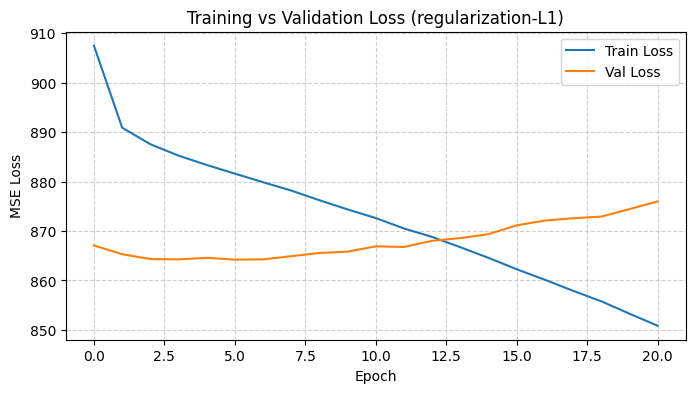

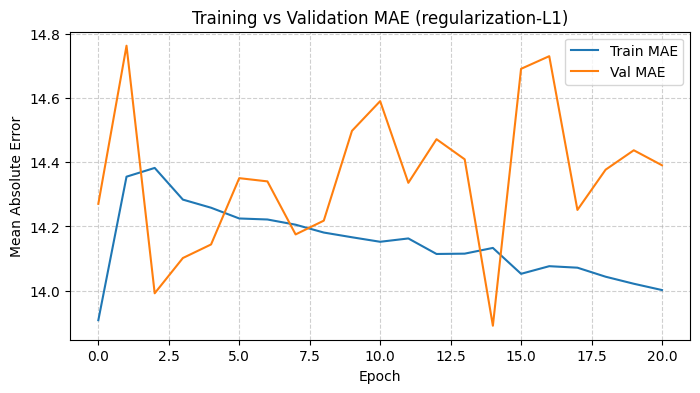

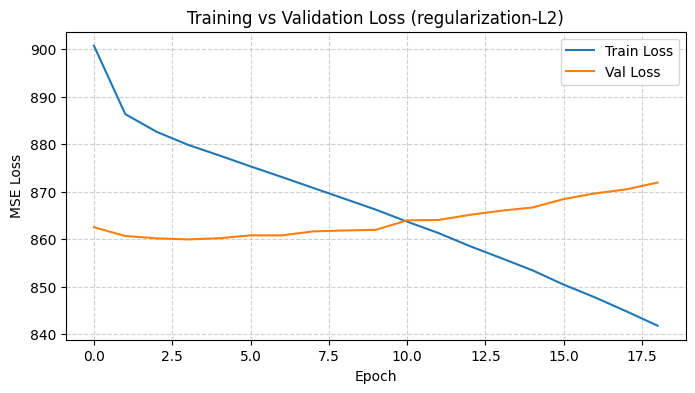

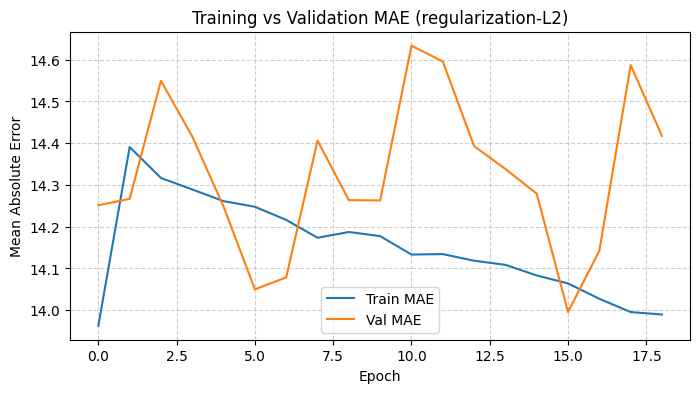

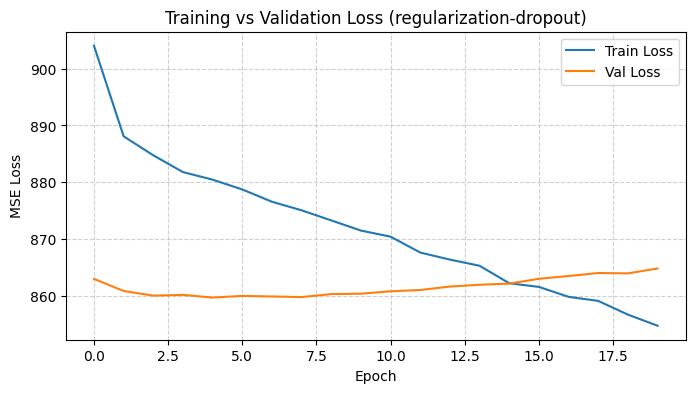

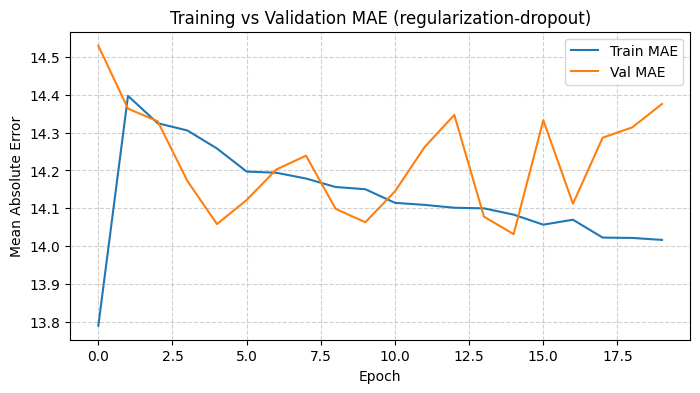

L1
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test MSE: 709.9789
Test MAE: 13.9138
Test R²: 0.0256
L2
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test MSE: 710.2884
Test MAE: 13.9830
Test R²: 0.0252
dropout
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test MSE: 709.0241
Test MAE: 13.6122
Test R²: 0.0269


(709.0240610798617, 13.612200889427214, 0.026912734778408942)

In [ ]:
# 畫 loss / mae 曲線(regulization)
plot_training_history(history_reg_L1, "(regularization-L1)")
plot_training_history(history_reg_L2, "(regularization-L2)")
plot_training_history(history_reg_Dropout, "(regularization-dropout)")

# 評估模型
print("L1")
evaluate_model(model_reg_L1, X_test_p, y_test)
print("L2")
evaluate_model(model_reg_L2, X_test_p, y_test)
print("dropout")
evaluate_model(model_reg_Dropout, X_test_p, y_test)

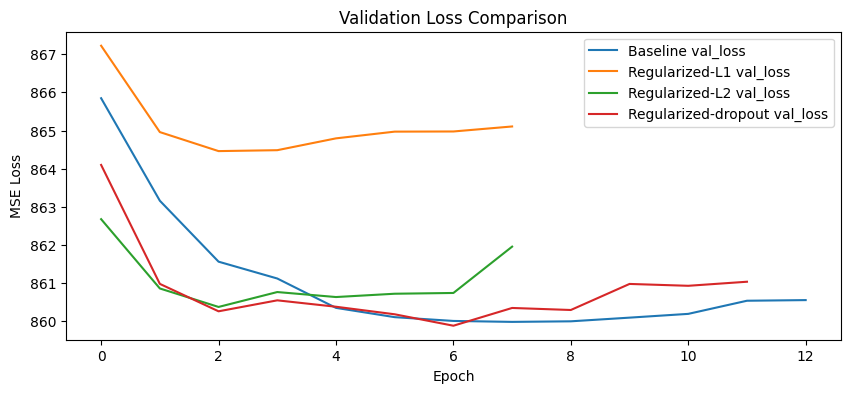

In [ ]:
# 畫圖比較訓練曲線
plt.figure(figsize=(10,4))
plt.plot(history.history['val_loss'], label='Baseline val_loss')
# plt.plot(history_tuned.history['val_loss'], label='Tuned val_loss')
plt.plot(history_reg_L1.history['val_loss'], label='Regularized-L1 val_loss')
plt.plot(history_reg_L2.history['val_loss'], label='Regularized-L2 val_loss')
plt.plot(history_reg_Dropout.history['val_loss'], label='Regularized-dropout val_loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


# Adaptive Learning Rate
本實驗比較了三種優化器：SGD、RMSprop 與 Adam。
從驗證損失（validation loss）曲線可以觀察到，RMSprop 的收斂最穩定且損失最低；
SGD 因採用固定學習率，收斂速度較慢；
而 Adam 在初期收斂速度最快，但在數個 epoch 之後出現不穩定現象，
推測可能是學習率對本資料集而言過高所致。

此結果顯示，自適應學習率方法（RMSprop 與 Adam）
能根據梯度自動調整更新步長，
使模型在訓練過程中能更快速且平滑地收斂，
相較於傳統固定學習率的 SGD，具有更佳的表現與穩定性。

Epoch 1/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 1016.0676 - mae: 12.1248 - val_loss: 867.8836 - val_mae: 13.8140 - learning_rate: 1.0000e-04
Epoch 2/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 854.3373 - mae: 13.9322 - val_loss: 864.1194 - val_mae: 14.0536 - learning_rate: 1.0000e-04
Epoch 3/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 881.7832 - mae: 14.0923 - val_loss: 862.8670 - val_mae: 13.9860 - learning_rate: 1.0000e-04
Epoch 4/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 878.8269 - mae: 14.1148 - val_loss: 861.4416 - val_mae: 14.0299 - learning_rate: 1.0000e-04
Epoch 5/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 844.6955 - mae: 13.9370 - val_loss: 861.4310 - val_mae: 13.9159 - learning_rate: 1.0000e-04
Epoch 6/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 892.0243 - mae: 13.9500 - val_loss: 861.3743 - val_mae: 13.8892 - learning_rate: 1.0000e-04
Epoch 7/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 886.0206 - ma

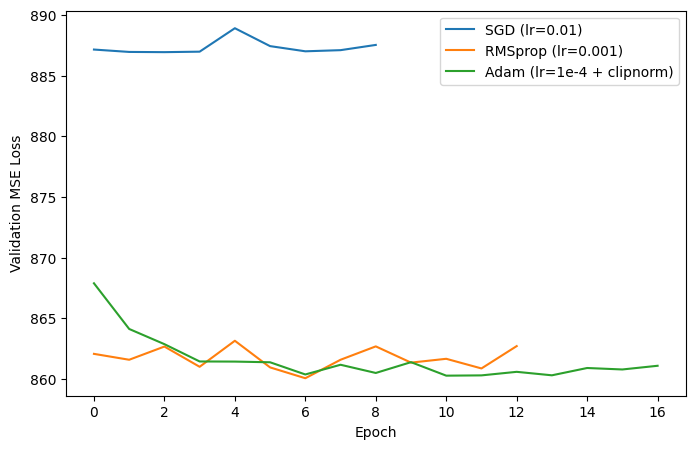

In [ ]:
from tensorflow.keras import models, layers, optimizers, callbacks
import matplotlib.pyplot as plt

def build_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    return model

input_dim = X_train_p.shape[1]
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# 試 Adam 小 lr + clipping
opt_adam = optimizers.Adam(learning_rate=1e-4, epsilon=1e-7, clipnorm=1.0)  # clipnorm 或 clipvalue

model_adam = build_model(input_dim)
model_adam.compile(optimizer=opt_adam, loss='mse', metrics=['mae'])
history_adam = model_adam.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=30, batch_size=64,
    callbacks=[es, reduce_lr],
    verbose=1
)

# RMSprop baseline (維持之前較好設定)
opt_rms = optimizers.RMSprop(learning_rate=0.001)
model_rms = build_model(input_dim)
model_rms.compile(optimizer=opt_rms, loss='mse', metrics=['mae'])
history_rms = model_rms.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=30, batch_size=64,
    callbacks=[es, reduce_lr],
    verbose=1
)

# SGD baseline (若要測)
opt_sgd = optimizers.SGD(learning_rate=0.01, momentum=0.9)
model_sgd = build_model(input_dim)
model_sgd.compile(optimizer=opt_sgd, loss='mse', metrics=['mae'])
history_sgd = model_sgd.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=30, batch_size=64,
    callbacks=[es, reduce_lr],
    verbose=1
)

# 畫比較圖
plt.figure(figsize=(8,5))
plt.plot(history_sgd.history['val_loss'], label='SGD (lr=0.01)')
plt.plot(history_rms.history['val_loss'], label='RMSprop (lr=0.001)')
plt.plot(history_adam.history['val_loss'], label='Adam (lr=1e-4 + clipnorm)')
plt.yscale('linear')
plt.xlabel('Epoch'); plt.ylabel('Validation MSE Loss'); plt.legend(); plt.show()


# A brief report in Google Colab

## 1. 架構 (Architecture)
- 資料集：OpenML ID 42728（Airlines_DepDelay_10M），目標變量為"DepDelay"（出發延誤時間）。
- 前處理：用ColumnTransformer，將數值特徵（numeric_cols）標準化，將類別特徵（categorical_cols）進行One-Hot Encoding
- 模型：用Keras的Sequential
  - 輸入層：形狀為特徵數（動態根據特徵選擇）。
  - 隱藏層：64，ReLU激活；32，ReLU激活。
  - 輸出層：1，線性激活（回歸）。
- **特徵選擇**：使用`RandomForestRegressor`計算特徵重要性，篩選前100個特徵。

## 2. 超參數 (Hyperparameters)
- 樣本數：100,000筆（隨機取樣，`random_state=42`）。
- 數據分割：訓練集：70,000筆（70%），驗證集：15,000筆（15%），測試集：15,000筆（15%）。
- batch_size：64。
- 學習率：0.001（Adam優化器）。
- epoch：50（搭配EarlyStopping，`patience=5`）。
- 特徵選擇：`n_estimators=100`，`n_jobs=-1`。

## 3. 分析 (Analysis)
- **資料特性**：原始資料約10M筆，取樣100,000筆後，經One-Hot Encoding後特徵從9個增至683個，顯示類別變量貢獻大。
- **性能**：目前R²約0.02-0.03，MAE約13.87-14.06，MSE約709-710，解釋力弱，可能因特徵選擇不佳或資料量不足。
- **問題**：驗證損失曲線顯示基線模型優於正則化（L1、L2、Dropout），可能因EarlyStopping過早中止或正則化參數過強。
- **改進方向**：
  - 測試更多特徵數（50-200），優化top_n。
  - 增加patience（10-15）或最小epoch（20），確保充分訓練。
  - 考慮減小batch_size（32）或使用數據生成器，解決記憶體不足。

## 結論
當前模型結構簡單，超參數已優化，但性能不理想。
feature selection部分已透過迴圈測試[50,100,150,200]選出最適合的數值，也有把patience提高，調整參數也都是用迴圈確認loss最低者，但baseline的loss卻是最低，加上回歸之後反而loss增加，或許是資料量不足或是本模型太簡單的緣故，但因資料量如果提高colab就說ram耗盡，所以最高只能sample到100000-500000，所以最後我已經找不到方法了，故以此模型繳交作業

# Transform Regression into Classification

把延誤時間（DepDelay）轉換為三個類別等級：
低延誤（Low，<5 分鐘）、中度延誤（Medium，5–20 分鐘）、以及 高延誤（High，>20 分鐘）。
這樣的分類方式能夠反映航班延誤在實際營運中的意義，
使模型重點關注「延誤的嚴重程度」而非「確切的延誤分鐘數」。

建立的模型為一個具有兩層隱藏層（分別含有 64 與 32 個神經元）的Feedforward Neural Network，
並採用 categorical crossentropy 以及 Adam 進行訓練。

最終模型在測試集上達到 0.7145% 的準確率。
根據混淆矩陣（confusion matrix）的結果，模型在「低延誤」類別上表現良好，
而「高延誤」、「中度延誤」的樣本相對較少，因此預測難度較高。

整體而言，將迴歸問題轉換為分類問題可降低資料中的雜訊影響，
並使模型輸出更具可解釋性與決策導向，
更符合實際航班管理與營運分析的需求。

In [ ]:
# 以 DepDelay 數值分三類
def delay_category(x):
    if x < 5:
        return 0  # Low delay
    elif x < 20:
        return 1  # Medium delay
    else:
        return 2  # High delay

# 建立新標籤
y_train_cls = y_train.apply(delay_category)
y_val_cls = y_val.apply(delay_category)
y_test_cls = y_test.apply(delay_category)


In [ ]:
# One-hot encode
from tensorflow.keras.utils import to_categorical

y_train_ohe = to_categorical(y_train_cls, num_classes=3)
y_val_ohe = to_categorical(y_val_cls, num_classes=3)
y_test_ohe = to_categorical(y_test_cls, num_classes=3)

In [ ]:
# FNN for Classification
from tensorflow.keras import models, layers, optimizers, callbacks

model_cls = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_p.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')  # softmax for 3-class classification
])

model_cls.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cls.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_93 (Dense)                │ (None, 64)             │        43,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,955 (179.51 KB)

 Trainable params: 45,955 (179.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cls = model_cls.fit(
    X_train_p, y_train_ohe,
    validation_data=(X_val_p, y_val_ohe),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6973 - loss: 0.8055 - val_accuracy: 0.7114 - val_loss: 0.7658
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7098 - loss: 0.7651 - val_accuracy: 0.7114 - val_loss: 0.7677
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7111 - loss: 0.7542 - val_accuracy: 0.7110 - val_loss: 0.7690
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7140 - loss: 0.7440 - val_accuracy: 0.7094 - val_loss: 0.7730
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7118 - loss: 0.7418 - val_accuracy: 0.7099 - val_loss: 0.7747
Epoch 6/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7145 - loss: 0.7324 - val_accuracy: 0.7083 - val_loss: 0.7794


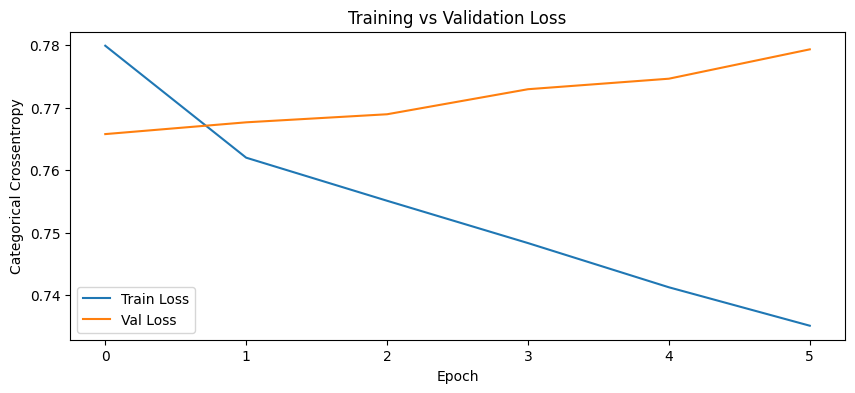

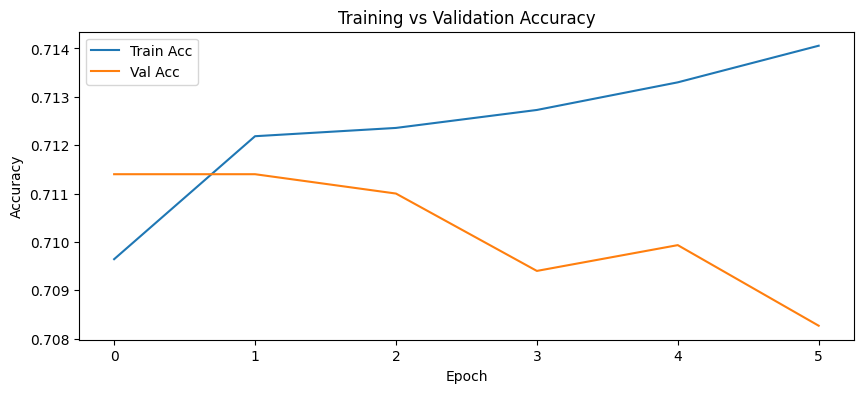

In [ ]:
# visulize
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history_cls.history['loss'], label='Train Loss')
plt.plot(history_cls.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Categorical Crossentropy')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history_cls.history['accuracy'], label='Train Acc')
plt.plot(history_cls.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7119 - loss: 0.7686
Test Accuracy: 0.7145
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


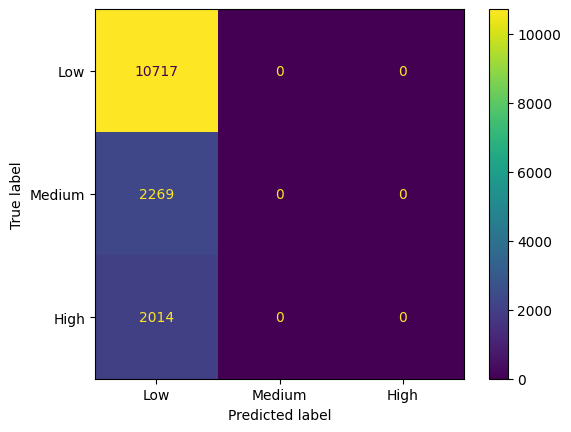

In [ ]:
# Evaluate on test data
test_loss, test_acc = model_cls.evaluate(X_test_p, y_test_ohe)
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_cls = np.argmax(model_cls.predict(X_test_p), axis=1)
cm = confusion_matrix(y_test_cls, y_pred_cls)
ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High']).plot()
